In [8]:
from __future__ import annotations
import time
import tkinter
import pathlib
import pickle
import tifffile
import os
import numpy as np
from PIL import (Image, ImageTk, ImageDraw)
from tkinter import filedialog, messagebox
from matplotlib.figure import Figure 
from matplotlib.backends.backend_tkagg import (FigureCanvasTkAgg, NavigationToolbar2Tk)
from matplotlib.patches import Rectangle, Circle
from matplotlib.backend_bases import MouseEvent
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.pyplot as plt
from skimage import measure
import fishCore
import fishGUI
import threading
import concurrent.futures
import cv2
import imageio.v3 as iio


f = fishCore.Fish(pathlib.Path("./config.ini"))
f.set_model_version("3.50")

c:\Users\tkpp2\miniconda3\envs\fish\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


final text_encoder_type: bert-base-uncased


[2025-10-11 16:25:58,547][INFO] CHECK: Model version 3.50 loaded


tif_files count: 18
example stems: ['MAXEXP250921COLC01_w1-DAPI_s001', 'MAXEXP250921COLC01_w1-DAPI_s002', 'MAXEXP250921COLC01_w1-DAPI_s003', 'MAXEXP250921COLC01_w1-DAPI_s004', 'MAXEXP250921COLC01_w1-DAPI_s005', 'MAXEXP250921COLC01_w1-DAPI_s006', 'MAXEXP250921COLC01_w2-AF555_s001', 'MAXEXP250921COLC01_w2-AF555_s002', 'MAXEXP250921COLC01_w2-AF555_s003', 'MAXEXP250921COLC01_w2-AF555_s004', 'MAXEXP250921COLC01_w2-AF555_s005', 'MAXEXP250921COLC01_w2-AF555_s006', 'MAXEXP250921COLC01_w3-AF488_s001', 'MAXEXP250921COLC01_w3-AF488_s002', 'MAXEXP250921COLC01_w3-AF488_s003', 'MAXEXP250921COLC01_w3-AF488_s004', 'MAXEXP250921COLC01_w3-AF488_s005', 'MAXEXP250921COLC01_w3-AF488_s006']
grouped keys: ['001', '002', '003', '004', '005', '006']
pos=001  channels=['488', '555', 'DAPI']
pos=002  channels=['488', '555', 'DAPI']
pos=003  channels=['488', '555', 'DAPI']
pos=004  channels=['488', '555', 'DAPI']
pos=005  channels=['488', '555', 'DAPI']
pos=006  channels=['488', '555', 'DAPI']
Using channel 555 f

DEBUG: DINO predicted 35 boxes


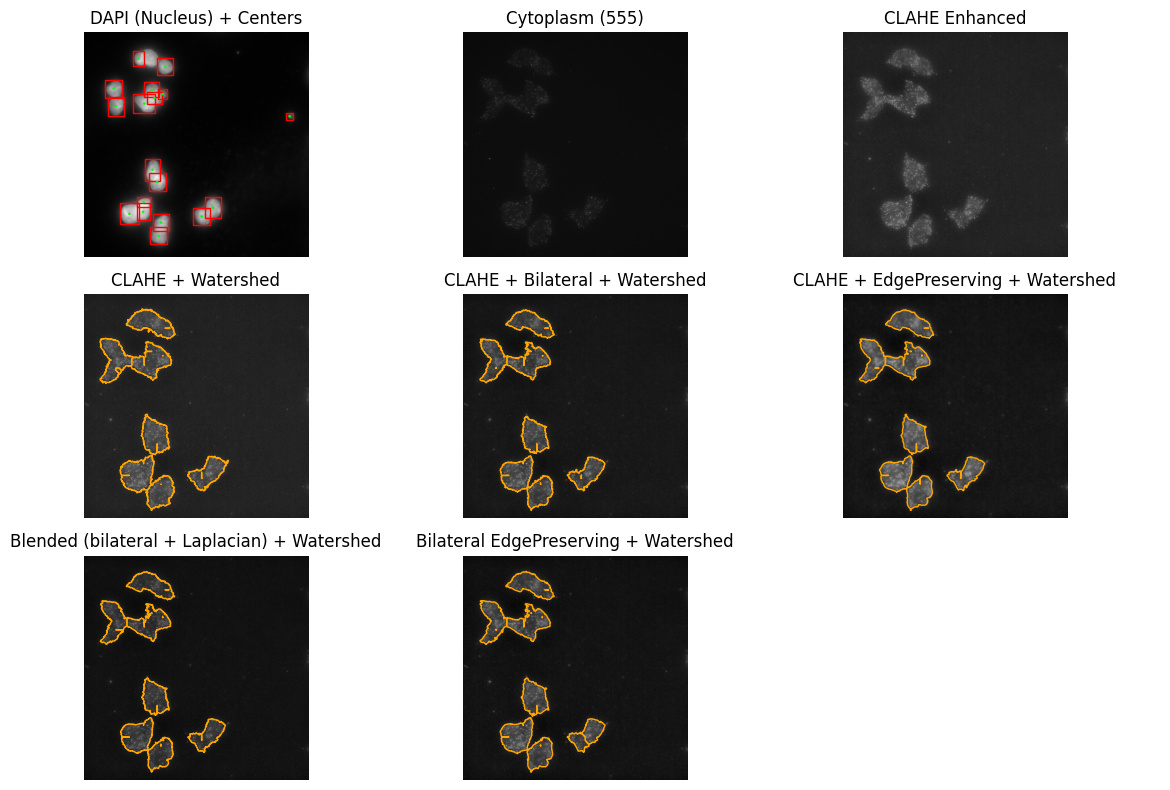

In [9]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def clahe_filter(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def watershed_segment(cyt_img: np.ndarray,
                      centers: list[tuple[float,float]],
                      thresh_method: str = "otsu",
                      min_size: int = 300) -> list[np.ndarray]:
    if thresh_method == "otsu":
        thresh = filters.threshold_otsu(cyt_img)
    else:
        thresh = np.percentile(cyt_img, 30)
    
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    binary = morphology.remove_small_objects(binary, min_size=1000)

    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for idx, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = idx

    labels = segmentation.watershed(-dist, markers, mask=binary)

    masks = []
    for i in range(1, len(centers)+1):
        cell = (labels == i)
        cell = postproc_mask(cell)
        masks.append(cell)
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------
import re
data_dir = pathlib.Path(r"C:\Users\tkpp2\Documents\FISH-ML2\assets\guohao_555\EXP250921COLC01")
tif_files = list(data_dir.glob("*.tif"))
grouped = {}

for path in tif_files:
    stem = path.stem
    pos_match = re.search(r"s(\d+)", stem, re.IGNORECASE)
    chan_match = re.search(r"w[-_]?(?:.*?)?(DAPI|488|647|555|594)", stem, re.IGNORECASE)
    if not (pos_match and chan_match):
        continue
    pos = pos_match.group(1)
    chan = chan_match.group(1).upper()
    grouped.setdefault(pos, {})[chan] = path

# quick debug: what files were found and how they were grouped
print("tif_files count:", len(tif_files))
print("example stems:", [p.stem for p in tif_files[:20]])
print("grouped keys:", sorted(grouped.keys()))
for pos, channels in grouped.items():
    print(f"pos={pos}  channels={sorted(channels.keys())}")

# Pick a sample (e.g., 001)
sample_id = "001"
if sample_id not in grouped or "555" not in grouped[sample_id]:
    raise ValueError(f"Sample s{sample_id} missing required channels")

nucleus_path = grouped[sample_id]["DAPI"]
nucleus = tifffile.imread(nucleus_path)
nucleus = normalize_to_uint8(nucleus)
cyto_channel = "555"
cyto_path = grouped[sample_id][cyto_channel]
print(f"Using channel {cyto_channel} for cytoplasm")

ch = tifffile.imread(cyto_path)
ch = normalize_to_uint8(ch)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(ch, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

clahe = clahe_filter(ch)
# grad = gradient(clahe)

# ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
sigma_est = estimate_sigma(clahe, channel_axis=-1, average_sigmas=True)
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

bilat1 = cv2.bilateralFilter(clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=sigma_norm, borderType=cv2.BORDER_REFLECT_101)
edge_preserved = cv2.edgePreservingFilter(clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)

bilat_edge = cv2.edgePreservingFilter(bilat1, flags=1, sigma_s=sigma_weak, sigma_r=0.4)

laplacian = cv2.Laplacian(ch, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)
blended = cv2.addWeighted(bilat1, 0.8, laplacian, 0.2, 0)

# ----- BBoxes and Masks -----
bbox_nucleus = f.AppIntDINOwrapper(nucleus)
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

masks_clahe = watershed_segment(clahe, centers)
# masks_grad = watershed_segment(grad, centers)
masks_bilat = watershed_segment(bilat1, centers)
masks_edge_preserved = watershed_segment(edge_preserved, centers)
masks_bilat_edge = watershed_segment(bilat_edge, centers)

# --------------------------------------
# Visualization
# --------------------------------------
# Visualization (fixed)
# --------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

# ---- Row 0 ----
# (0,0) DAPI nucleus + centers
axes[0, 0].imshow(nucleus, cmap='gray')
axes[0, 0].set_title("DAPI (Nucleus) + Centers")
axes[0, 0].axis('off')
for (x1, y1, x2, y2) in bbox_nucleus:
    axes[0, 0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   edgecolor='red', facecolor='none', linewidth=1))
for cx, cy in centers:
    axes[0, 0].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))

# (0,1) Cytoplasm original
axes[0, 1].imshow(ch, cmap='gray')
axes[0, 1].set_title(f"Cytoplasm ({cyto_channel})")
axes[0, 1].axis('off')

# (0,2) CLAHE enhanced
axes[0, 2].imshow(clahe, cmap='gray')
axes[0, 2].set_title("CLAHE Enhanced")
axes[0, 2].axis('off')

# ---- Row 1 ----
# CLAHE + Watershed
axes[1, 0].imshow(clahe, cmap='gray')
axes[1, 0].set_title("CLAHE + Watershed")
axes[1, 0].axis('off')
for mask in masks_clahe:
    for contour in measure.find_contours(mask, 0.5):
        axes[1, 0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# Bilateral (on CLAHE) + Watershed  <-- show bilat1 here
axes[1, 1].imshow(bilat1, cmap='gray')
axes[1, 1].set_title("CLAHE + Bilateral + Watershed")
axes[1, 1].axis('off')
for mask in masks_bilat:
    for contour in measure.find_contours(mask, 0.5):
        axes[1, 1].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# EdgePreserving (on CLAHE) + Watershed  <-- show edge_preserved here
axes[1, 2].imshow(edge_preserved, cmap='gray')
axes[1, 2].set_title("CLAHE + EdgePreserving + Watershed")
axes[1, 2].axis('off')
for mask in masks_edge_preserved:
    for contour in measure.find_contours(mask, 0.5):
        axes[1, 2].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# ---- Row 2 ----
# Blended + Watershed
masks_blended = watershed_segment(blended, centers)
axes[2, 0].imshow(blended, cmap='gray')
axes[2, 0].set_title("Blended (bilateral + Laplacian) + Watershed")
axes[2, 0].axis('off')
for mask in masks_blended:
    for contour in measure.find_contours(mask, 0.5):
        axes[2, 0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

# Bilateral EdgePreserving + Watershed
axes[2, 1].imshow(bilat_edge, cmap='gray')
axes[2, 1].set_title("Bilateral EdgePreserving + Watershed")
axes[2, 1].axis('off')
for mask in masks_bilat_edge:
    for contour in measure.find_contours(mask, 0.5):
        axes[2, 1].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')

axes[2, 2].axis('off')

plt.tight_layout()
plt.show()


Estimated Gaussian noise standard deviation = 6.090427616979958
Estimated Gaussian noise standard deviation = 21.41920260893804
DEBUG: Running dino_bbox
DEBUG: DINO predicted 35 boxes
[CYTO] Starting prediction for 7 cells
[CYTO] Input image shape: (2048, 2048, 3), dtype: uint8
[CYTO] Using pre-formatted 3-channel image as RGB
[CYTO] Processing box [153.0, 410.0, 441.0, 807.0]
[CYTO] Processing box [951.0, 1487.0, 1297.0, 1792.0]
[CYTO] Processing box [532.0, 1099.0, 781.0, 1462.0]
[CYTO] Processing box [583.0, 1658.0, 819.0, 1971.0]
[CYTO] Processing box [390.0, 144.0, 830.0, 400.0]
[CYTO] Processing box [337.0, 1478.0, 638.0, 1805.0]
[CYTO] Processing box [433.0, 439.0, 795.0, 781.0]


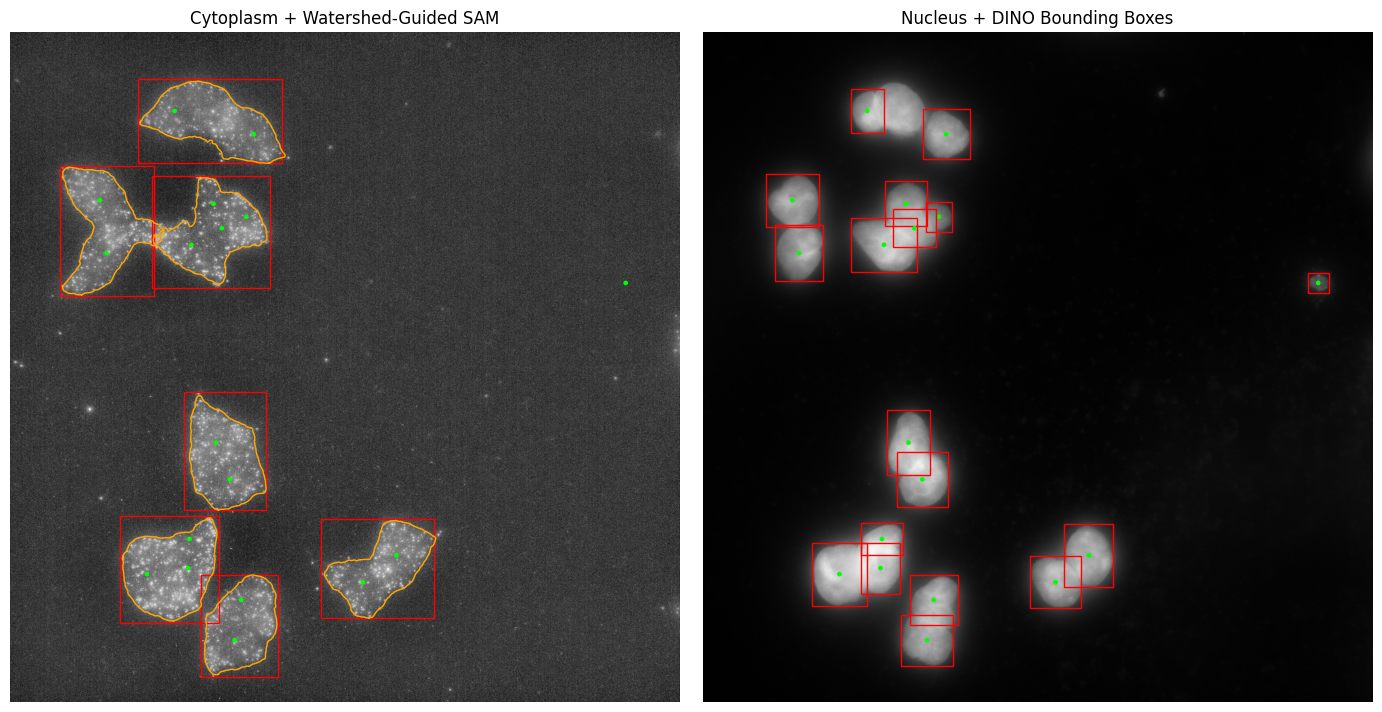

In [10]:
import cv2
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from skimage import filters, morphology, measure, segmentation
from scipy import ndimage as ndi
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
)
import pathlib

# --------------------------------------
# Helper functions
# --------------------------------------
def remove_outliers(img, k=20.0, use_median=False):
    """
    Clip values that are more than k std-dev (or MAD units) above center.
    Args:
        img: 16-bit numpy array
        k: threshold (e.g. 3σ)
        use_median: if True use median+MAD, else mean+std
    Returns:
        clipped float32 image in [0,1]
    """
    x = img.astype(np.float32)

    if use_median:
        med = np.median(x)
        mad = np.median(np.abs(x - med)) + 1e-6
        sigma = 1.4826 * mad  # robust std estimate
        thresh = med + k * sigma
    else:
        mean = np.mean(x)
        std = np.std(x)
        thresh = mean + k * std

    # clip outliers
    x_clipped = np.minimum(x, thresh)

    # normalize after clipping (to 0..1)
    x_norm = (x_clipped - x_clipped.min()) / (x_clipped.max() - x_clipped.min() + 1e-6)
    return x_norm

def normalize_to_uint8(img):
    return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def calculate_sigma(img):
    # ----- ESTIMATE SIGMA - Due to clipping in random_noise, the estimate will be a bit smaller than the specified sigma.
    sig = estimate_sigma(img, channel_axis=None, average_sigmas=True)
    print(f'Estimated Gaussian noise standard deviation = {sig}')
    return sig

def clahe_filter(img, clip_limit=4.0, tile_size=(8,8)):
    c = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return c.apply(img)

def laplacian(img, cyt_bilat):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    lap = cv2.convertScaleAbs(lap)
    cyt_blended = cv2.addWeighted(cyt_bilat, 0.8, lap, 0.2, 0)
    return cyt_blended

def brightness(img, target_mean=70):
    mean_val = np.mean(img)

    # Compute needed offset (positive = brighten, negative = darken)
    offset = target_mean - mean_val
    # Build a constant image for addition
    adjustment = np.full(img.shape, offset, dtype=np.uint8) if offset > 0 else np.zeros_like(img)
    # Use cv.add to brighten, cv.subtract to darken
    if offset > 0:
        print("Brightness increased")
        result = cv2.add(img, adjustment)
    else:
        print("Brightness remained the same")
        result = img

    return result

def postproc_mask(m):
    m = morphology.remove_small_objects(m.astype(bool), min_size=200)
    m = morphology.binary_closing(m, footprint=morphology.disk(3))
    m = morphology.binary_opening(m, footprint=morphology.disk(2))
    return m.astype(np.uint8)

def mask_to_bbox(mask):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    return (xs.min(), ys.min(), xs.max(), ys.max())

def watershed_segment_with_centers(cyt_img, centers):
    thresh = filters.threshold_otsu(cyt_img)
    binary = cyt_img > thresh
    binary = morphology.remove_small_holes(binary, area_threshold=1000)
    # binary = morphology.remove_small_objects(binary, min_size=1000)
    dist = ndi.distance_transform_edt(binary)

    markers = np.zeros(cyt_img.shape, dtype=np.int32)
    for i, (cx, cy) in enumerate(centers, start=1):
        xi, yi = int(round(cx)), int(round(cy))
        if 0 <= yi < cyt_img.shape[0] and 0 <= xi < cyt_img.shape[1]:
            markers[yi, xi] = i

    edges = filters.sobel(cyt_img)
    elevation = -dist + 5 * edges
    labels = segmentation.watershed(elevation, markers=markers, mask=binary)

    masks = []
    for i in range(1, np.max(labels)+1):
        mask = (labels == i)
        if np.sum(mask) > 0:
            masks.append(postproc_mask(mask))
    return masks

# --------------------------------------
# Load image and preprocess
# --------------------------------------

# ----- COMPOSITE IMAGES -----
# image_path = pathlib.Path("C:/Users/msgal/Downloads/Ding_Lab/FISH-ML/Composite Images (Multi-Channel)/488_pb5sp4_s1.composite.tif")

# with tifffile.TiffFile(image_path) as tif:
#     cyt = tif.pages[0].asarray() # testing with 488
#     nucleus = tif.pages[1].asarray()

# ----- NON COMPOSITE IMAGES -----
cyt_path = r"assets/guohao_555/EXP250921COLC01/MAXEXP250921COLC01_w2-AF555_s001.tif"
nuc_path = r"C:\Users\tkpp2\Documents\FISH-ML2\assets\guohao_555\EXP250921COLC01\MAXEXP250921COLC01_w1-DAPI_s001.tif" 

with tifffile.TiffFile(cyt_path) as tif:
    cyt = tif.pages[0].asarray() # testing with 488

with tifffile.TiffFile(nuc_path) as tif:
    nucleus = tif.pages[0].asarray()

cyt_removed = remove_outliers(cyt)
cyt_norm = normalize_to_uint8(cyt_removed)

sigma_est = calculate_sigma(cyt) # Calculate sigma

cyt_clahe = clahe_filter(cyt_norm) 

sigma_est = calculate_sigma(cyt_clahe)
sigma_norm = sigma_est + 3.0
sigma_weak = sigma_est - 10.0

cyt_bilat = cv2.bilateralFilter(cyt_clahe, d=9, sigmaColor=sigma_norm, sigmaSpace=15, borderType=cv2.BORDER_REFLECT_101)
cyt_edge_preserved = cv2.edgePreservingFilter(cyt_clahe, flags=1, sigma_s=sigma_norm, sigma_r=0.4)
cyt_bilat_edge = cv2.edgePreservingFilter(cyt_bilat, flags=1, sigma_s=sigma_weak, sigma_r=0.4)
cyt_blended = laplacian(cyt_norm, cyt_bilat)

# --------
# Stacking
# --------
cyt_rgb = np.stack([cyt_blended, cyt_bilat, cyt_edge_preserved], axis=-1)
bbox_nucleus = f.AppIntDINOwrapper(nucleus) 
centers = [((x1 + x2) / 2, (y1 + y2) / 2) for x1, y1, x2, y2 in bbox_nucleus]

# --- Creating Masks ---
masks_bilat_edge = watershed_segment_with_centers(cyt_bilat_edge, centers)

# --- Creating BBoxes ---
bbox_cyto = [mask_to_bbox(m) for m in masks_bilat_edge]
bbox_cyto = [b for b in bbox_cyto if b is not None]
bbox_cyto = [
    [float(x1), float(y1), float(x2), float(y2)] 
    for (x1, y1, x2, y2) in bbox_cyto
]


# -----------------------------
# SAM segmentation guided by boxes
# -----------------------------
masks_all = f.finetune.AppIntPREDICTCytoplasmWrapper(cyt_rgb, bbox_cyto)

masks = []
for mset in masks_all:
    areas = [(mm > 0).sum() for mm in mset]
    best = mset[np.argmax(areas)]
    masks.append(postproc_mask(best))

# --------------------------------------
# Visualization
# --------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Cytoplasm + masks
ax[0].imshow(cyt_clahe, cmap='gray')
ax[0].set_title("Cytoplasm + Watershed-Guided SAM")
ax[0].axis('off')
for (x1, y1, x2, y2) in bbox_cyto:
    # if not (x1 <= cx <= x2 and y1 <= cy <= y2):
    #     print(f"Center at ({cx:.1f}, {cy:.1f}) is OUTSIDE bbox: ({x1:.1f}, {y1:.1f}) → ({x2:.1f}, {y2:.1f})")
    ax[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    # ax[0].add_patch(Circle((cx, cy), radius=5, color='red', fill=True))
for mask in masks:
    for contour in measure.find_contours(mask, 0.5):
        ax[0].plot(contour[:, 1], contour[:, 0], linewidth=1, color='orange')
# Debug: plot all nucleus centers in cytoplasm plot
for (cx, cy) in centers:
    ax[0].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))


# Nucleus with bounding boxes
ax[1].imshow(nucleus, cmap='gray')
ax[1].set_title("Nucleus + DINO Bounding Boxes")
ax[1].axis('off')
for (x1, y1, x2, y2), (cx, cy) in zip(bbox_nucleus, centers):
    ax[1].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, edgecolor='red', facecolor='none', lw=1))
    ax[1].add_patch(Circle((cx, cy), radius=5, color='lime', fill=True))

plt.tight_layout()
plt.show()